# **Customer Churn Prediction System**

# Objective
Develop a machine learning model that predicts whether a customer is likely to leave a telecom company. Build a complete pipeline including data preprocessing, model training, evaluation, and a simple prediction interface.



## Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import joblib

# Phase 1

## Load Dataset

In [3]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Basic Information

In [4]:
df.info()

df.describe()

df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


(7043, 21)

## Missing Values

In [5]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


## Convert TotalCharges

In [6]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

## Fill Missing Values

In [7]:
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

/tmp/ipykernel_618/1479199042.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)


## Check Duplicates

In [8]:
df.duplicated().sum()

np.int64(0)

## Five Visualizations

### 1 Customer Churn Distribution

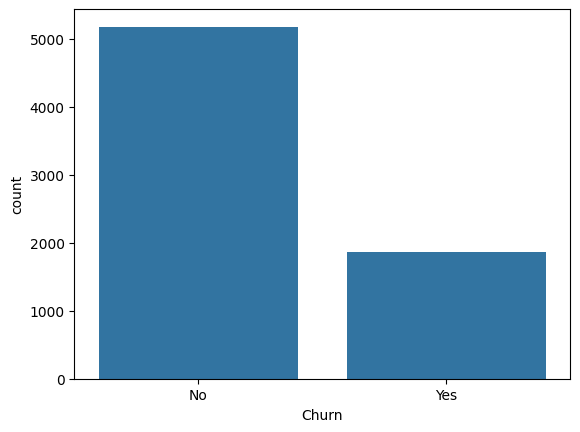

In [9]:
sns.countplot(x="Churn", data=df)

plt.show()

### 2 Gender Distribution

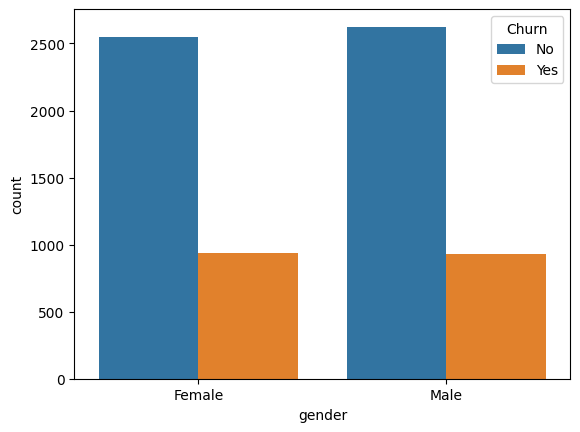

In [10]:
sns.countplot(x="gender", hue="Churn", data=df)

plt.show()

### 3 Contract Type

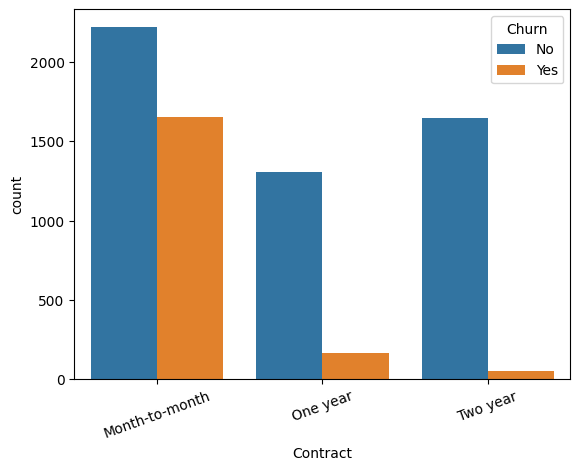

In [11]:
sns.countplot(x="Contract", hue="Churn", data=df)

plt.xticks(rotation=20)

plt.show()

### 4 Monthly Charges

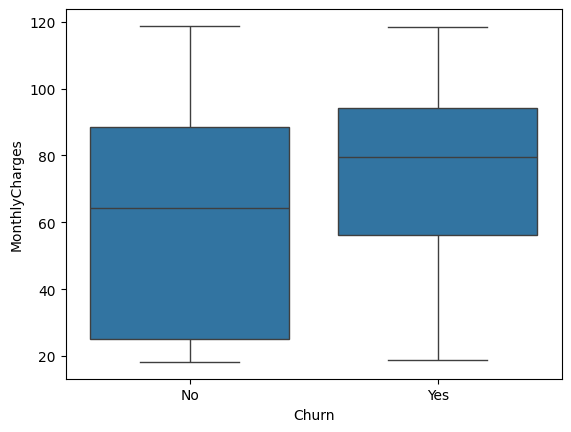

In [12]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)

plt.show()

### 5 Tenure

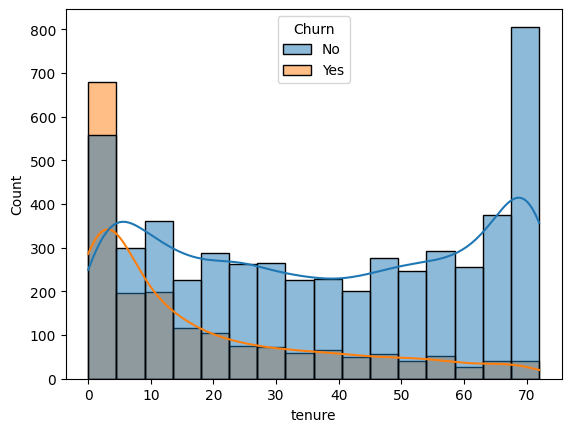

In [13]:
sns.histplot(data=df,
             x="tenure",
             hue="Churn",
             kde=True)

plt.show()

# Phase 2

## Data Preprocessing

In [14]:
df.drop("customerID", axis=1, inplace=True)

## Encode Target

In [15]:
df["Churn"] = df["Churn"].map({
    "Yes":1,
    "No":0
})

## Label Encoding

In [16]:
encoder = LabelEncoder()

for col in df.columns:

    if df[col].dtype=="object":

        df[col]=encoder.fit_transform(df[col])

## Feature & Target

In [17]:
X=df.drop("Churn",axis=1)

y=df["Churn"]

## Train Test Split

In [18]:
X_train,X_test,y_train,y_test=train_test_split(

X,
y,
test_size=0.2,
random_state=42
)

## Standardization

In [19]:
scaler=StandardScaler()

X_train=scaler.fit_transform(X_train)

X_test=scaler.transform(X_test)

# Phase 3

## Logistic Regression

In [20]:
lr=LogisticRegression()

lr.fit(X_train,y_train)

lr_pred=lr.predict(X_test)

## Random Forest

In [21]:
rf=RandomForestClassifier()

rf.fit(X_train,y_train)

rf_pred=rf.predict(X_test)

## Gradient Boosting

In [22]:
gb=GradientBoostingClassifier()

gb.fit(X_train,y_train)

gb_pred=gb.predict(X_test)

# Phase 4

## Evaluation Function

In [23]:
def evaluate(name,y_true,pred):

    print(name)

    print("Accuracy:",accuracy_score(y_true,pred))

    print("Precision:",precision_score(y_true,pred))

    print("Recall:",recall_score(y_true,pred))

    print("F1:",f1_score(y_true,pred))

    print("ROC:",roc_auc_score(y_true,pred))

    print(confusion_matrix(y_true,pred))

## Run

In [24]:
evaluate("Logistic Regression",y_test,lr_pred)

evaluate("Random Forest",y_test,rf_pred)

evaluate("Gradient Boosting",y_test,gb_pred)

Logistic Regression
Accuracy: 0.815471965933286
Precision: 0.677115987460815
Recall: 0.579088471849866
F1: 0.6242774566473989
ROC: 0.7398338112145082
[[933 103]
 [157 216]]
Random Forest
Accuracy: 0.8005677785663591
Precision: 0.6755725190839694
Recall: 0.4745308310991957
F1: 0.5574803149606299
ROC: 0.6962422495264319
[[951  85]
 [196 177]]
Gradient Boosting
Accuracy: 0.8055358410220014
Precision: 0.671280276816609
Recall: 0.5201072386058981
F1: 0.5861027190332326
ROC: 0.7142041984535281
[[941  95]
 [179 194]]


## Comparison Table

| Model                   |   Accuracy |  Precision |     Recall |   F1-Score |    ROC-AUC |
| ----------------------- | ---------: | ---------: | ---------: | ---------: | ---------: |
| **Logistic Regression** | **81.55%** | **67.71%** | **57.91%** | **62.43%** | **73.98%** |
| **Random Forest**       | **80.06%** | **67.56%** | **47.45%** | **55.75%** | **69.62%** |
| **Gradient Boosting**   | **80.55%** | **67.13%** | **52.01%** | **58.61%** | **71.42%** |
